Dynamic effects plot saved to ../outputs/dynamic_effects_plot.png
Event study regression table saved.
Interaction effects regression table saved.

--- Interaction Model Summary ---
                            OLS Regression Results                            
Dep. Variable:         Players_scaled   R-squared:                       0.374
Model:                            OLS   Adj. R-squared:                  0.371
Method:                 Least Squares   F-statistic:                     108.4
Date:                Tue, 05 May 2026   Prob (F-statistic):           4.84e-55
Time:                        09:34:36   Log-Likelihood:                -641.02
No. Observations:                 548   AIC:                             1290.
Df Residuals:                     544   BIC:                             1307.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


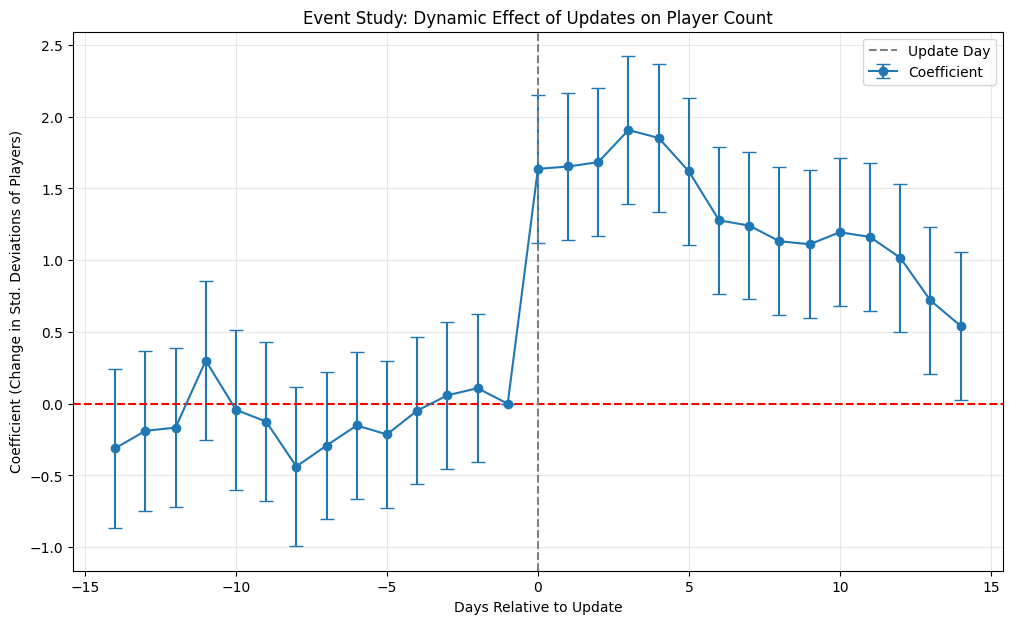

In [ ]:
import pandas as pd
import statsmodels.api as sm
from tabulate import tabulate
import os
import matplotlib.pyplot as plt
import numpy as np

# List of games to analyze
games = [
    {"name": "Palworld", "file": "../data:clean/palworld_2024-12-09_to_2025-01-13.csv", "update": "2024-12-23", "controls": ['holiday_overlap', 'sale_overlap']},
    {"name": "Warframe", "file": "../data:clean/warframe_2025-11-26_to_2025-12-31.csv", "update": "2025-12-10", "controls": ['promo_event_overlap']},
    {"name": "Counter-Strike 2", "file": "../data:clean/counter_strike_2_2024-04-23_to_2024-05-28.csv", "update": "2024-05-07", "controls": ['monetization_overlap', 'competitive_cycle_overlap']},
    {"name": "Sea of Thieves", "file": "../data:clean/sea_of_thieves_2024-10-03_to_2024-11-07.csv", "update": "2024-10-17", "controls": ['season_launch_overlap', 'holiday_overlap']},
    {"name": "PUBG: BATTLEGROUNDS", "file": "../data:clean/pubg__battlegrounds_2025-10-22_to_2025-11-26.csv", "update": "2025-11-05", "controls": ['licensed_collab_overlap', 'competitive_cycle_overlap']},
    {"name": "Dead by Daylight", "file": "../data:clean/dead_by_daylight_2023-11-14_to_2023-12-19.csv", "update": "2023-11-28", "controls": ['dlc_expansion_overlap', 'licensed_collab_overlap', 'sale_overlap']},
    {"name": "Don't Starve Together", "file": "../data:clean/don_t_starve_together_2023-04-13_to_2023-05-18.csv", "update": "2023-04-27", "controls": []},
    {"name": "Deep Rock Galactic", "file": "../data:clean/deep_rock_galactic_2024-05-30_to_2024-07-04.csv", "update": "2024-06-13", "controls": ['season_launch_overlap', 'sale_overlap']},
    {"name": "Apex Legends", "file": "../data:clean/apex_legends_2025-01-28_to_2025-03-04.csv", "update": "2025-02-11", "controls": ['season_launch_overlap', 'competitive_cycle_overlap']},
    {"name": "Destiny 2", "file": "../data:clean/destiny_2_2024-09-24_to_2024-10-29.csv", "update": "2024-10-08", "controls": ['season_launch_overlap', 'dlc_expansion_overlap']},
    {"name": "No Man's Sky", "file": "../data:clean/no_man_s_sky_2025-01-15_to_2025-02-19.csv", "update": "2025-01-29", "controls": []},
    {"name": "HELLDIVERS 2", "file": "../data:clean/helldivers_2_2025-08-19_to_2025-09-23.csv", "update": "2025-09-02", "controls": ['monetization_overlap', 'promo_event_overlap']},
    {"name": "Path of Exile", "file": "../data:clean/path_of_exile_2025-06-06_to_2025-07-04.csv", "update": "2025-06-13", "controls": ['season_launch_overlap', 'promo_event_overlap']},
    {"name": "Rainbow Six Siege", "file": "../data:clean/rainbow_six_siege_2024-08-19_to_2024-09-16.csv", "update": "2024-08-26", "controls": ['season_launch_overlap', 'competitive_cycle_overlap', 'monetization_overlap']},
    {"name": "The Finals", "file": "../data:clean/the_finals_2024-12-05_to_2025-01-02.csv", "update": "2024-12-12", "controls": ['season_launch_overlap', 'anniversary_overlap', 'holiday_overlap', 'sale_overlap']},
    {"name": "V Rising", "file": "../data:clean/v_rising_2025-04-21_to_2025-05-19.csv", "update": "2025-04-28", "controls": []}
 ]

all_games_df = pd.DataFrame()
all_control_vars = set()
for game in games:
    all_control_vars.update(game['controls'])

for game in games:
    df = pd.read_csv(game['file'])
    df['DateTime'] = pd.to_datetime(df['DateTime'])
    update_date = pd.to_datetime(game['update'])
    df['game'] = game['name']
    df['days_from_update'] = (df['DateTime'] - update_date).dt.days
    all_games_df = pd.concat([all_games_df, df])

all_games_df['Players_scaled'] = all_games_df.groupby('game')['Players'].transform(lambda x: (x - x.mean()) / x.std())
all_games_df = all_games_df.dropna(subset=['Players_scaled'])

# Only keep control labels that actually exist in the cleaned data.
control_cols = [control for control in sorted(all_control_vars) if control in all_games_df.columns]

# --- 1. Event Study / Dynamic Effects --- #
event_window = 14 # days before and after
filtered_df = all_games_df[all_games_df['days_from_update'].abs() <= event_window].copy()

# Create dummy variables for each day relative to the update
# We omit one day (e.g., day before update, -1) as the reference category
event_dummies = pd.get_dummies(filtered_df['days_from_update'], prefix='day')
event_dummies = event_dummies.drop('day_-1', axis=1) # Drop reference category

# Add control variables that are actually available
for control in control_cols:
    event_dummies[control] = filtered_df[control]

y = filtered_df['Players_scaled'].astype(float)
X = sm.add_constant(event_dummies.astype(float))

event_model = sm.OLS(y, X).fit()

# Prepare data for plotting
day_coeffs_indices = [c for c in event_model.params.index if c.startswith('day_')]
coeffs = event_model.params[day_coeffs_indices]
conf_int = event_model.conf_int().loc[day_coeffs_indices]
days = [int(c.replace('day_', '')) for c in coeffs.index]

# Add the reference day back in with a coefficient of 0
plot_data = pd.DataFrame({
    'day': days,
    'coeff': coeffs.values,
    'conf_low': conf_int[0],
    'conf_high': conf_int[1]
}).sort_values('day').reset_index(drop=True)

plot_data = pd.concat([plot_data, pd.DataFrame({'day': [-1], 'coeff': [0], 'conf_low': [0], 'conf_high': [0]})], ignore_index=True).sort_values('day')

# Plotting the dynamic effects
plt.figure(figsize=(12, 7))
plt.errorbar(plot_data['day'], plot_data['coeff'], yerr=[plot_data['coeff'] - plot_data['conf_low'], plot_data['conf_high'] - plot_data['coeff']], fmt='-o', capsize=5, label='Coefficient')
plt.axhline(0, color='red', linestyle='--')
plt.axvline(0, color='grey', linestyle='--', label='Update Day')
plt.title('Event Study: Dynamic Effect of Updates on Player Count')
plt.xlabel('Days Relative to Update')
plt.ylabel('Coefficient (Change in Std. Deviations of Players)')
plt.grid(True, alpha=0.3)
plt.legend()

output_dir = '../outputs'
os.makedirs(output_dir, exist_ok=True)
plot_path = os.path.join(output_dir, 'Figure_2_Dynamic_Effects.png')
plt.savefig(plot_path)
print(f'Dynamic effects plot saved to {plot_path}')

# --- 2. Interaction Effects --- #
# Categorize games as primarily Co-op or PvP
coop_games = ['Palworld', 'Warframe', 'Sea of Thieves', "Don't Starve Together", 'Deep Rock Galactic', 'Destiny 2', 'No Man\'s Sky', 'HELLDIVERS 2', 'V Rising']
all_games_df['is_coop'] = all_games_df['game'].isin(coop_games).astype(int)
all_games_df['post_update'] = (all_games_df['days_from_update'] >= 0).astype(int)

# Create the interaction term
all_games_df['interaction'] = all_games_df['post_update'] * all_games_df['is_coop']

y_interact = all_games_df['Players_scaled']
X_interact = all_games_df[['post_update', 'is_coop', 'interaction'] + control_cols]
X_interact = sm.add_constant(X_interact)

interaction_model = sm.OLS(y_interact, X_interact).fit()

# --- Generate and Save Tables --- #
def create_regression_table(model, model_name):
    return model.summary().as_text()

event_table = event_model.summary().as_html()
interaction_table = interaction_model.summary().as_html()

with open(os.path.join(output_dir, 'Table_2_Event_Study_Coefficients.html'), 'w') as f:
    f.write(event_table)
print('Event study regression table saved.')

with open(os.path.join(output_dir, 'interaction_effects_table.html'), 'w') as f:
    f.write(interaction_table)
print('Interaction effects regression table saved.')

print('\n--- Interaction Model Summary ---')
print(interaction_model.summary())
